In [1]:
import numpy as np

np.random.seed(42)

X = np.random.randn(5, 10, 3)              
y = np.random.randint(0, 2, (5, 1))       

samples = X.shape[0]
seq_len = X.shape[1]
input_size = X.shape[2]
hidden_size = 4
output_size = 1

Wz = np.random.randn(input_size + hidden_size, hidden_size) * 0.01
Wr = np.random.randn(input_size + hidden_size, hidden_size) * 0.01
Wh = np.random.randn(input_size + hidden_size, hidden_size) * 0.01

bz = np.zeros((1, hidden_size))
br = np.zeros((1, hidden_size))
bh = np.zeros((1, hidden_size))

Wy = np.random.randn(hidden_size, output_size) * 0.01
by = np.zeros((1, output_size))

lr = 0.01

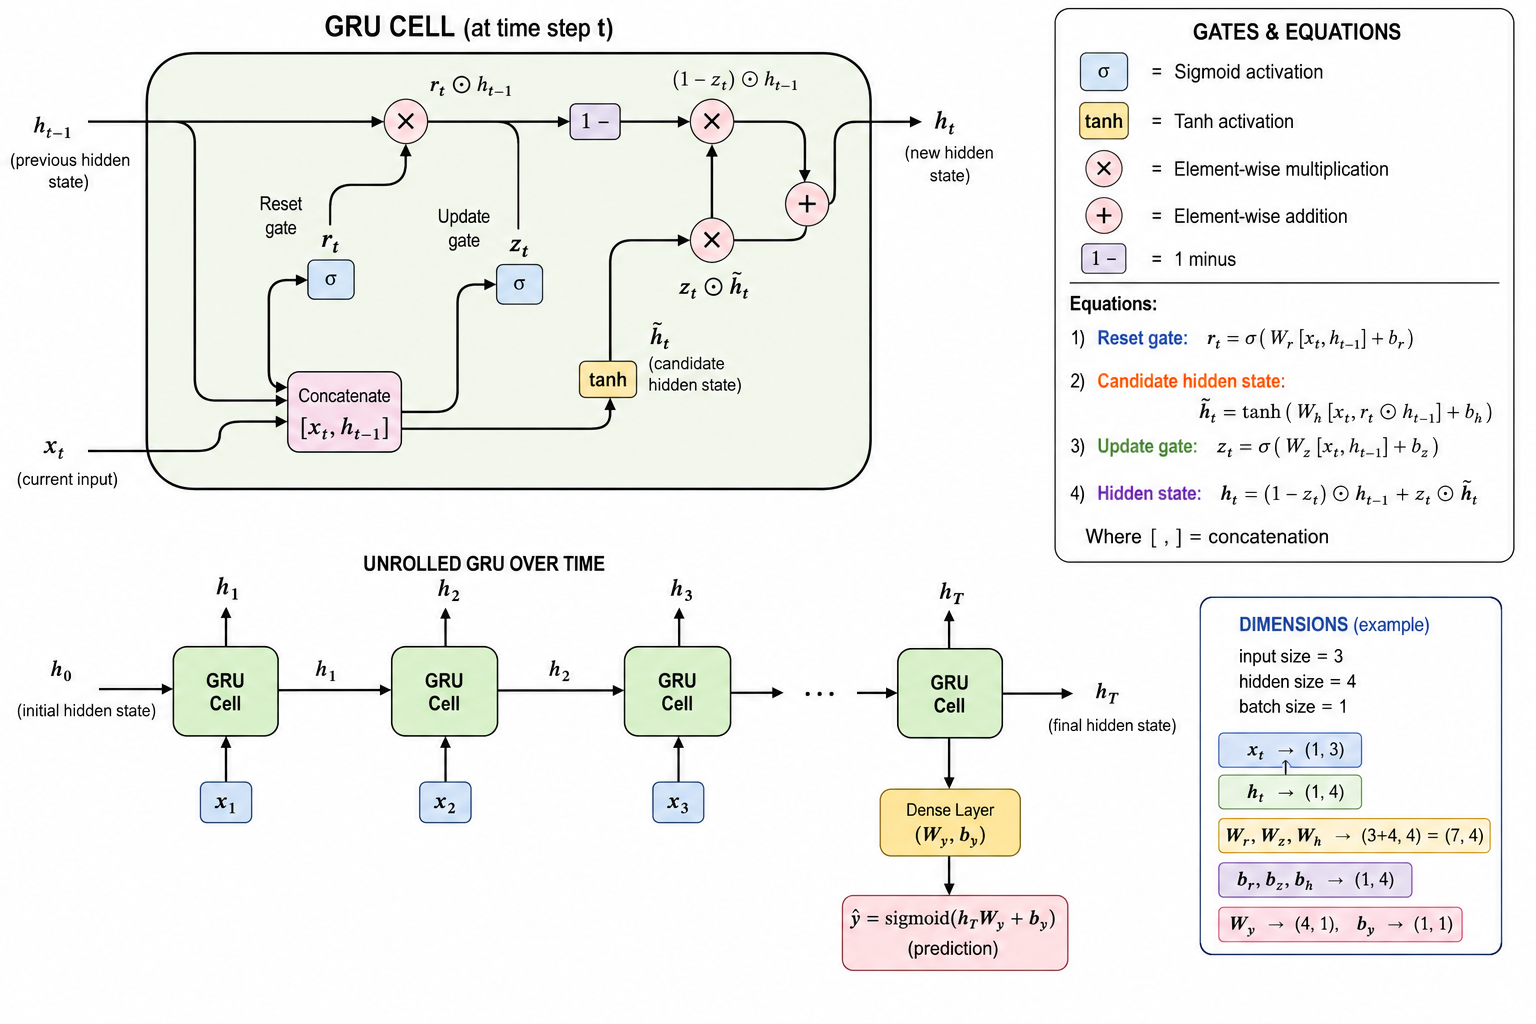

In [2]:
for epoch in range(1000):
    for sample in range(samples):

        # Initial hidden state
        h = np.zeros((1, hidden_size))

        # Process one sequence
        for t in range(seq_len):
            x = X[sample, t].reshape(1, -1)

            # ---------------- Reset Gate ----------------
            combined = np.concatenate((x, h), axis=1)

            r = np.dot(combined, Wr) + br
            rt = 1 / (1 + np.exp(-r))

            # ---------------- Candidate Hidden State ----------------
            past = rt * h

            combined_candidate = np.concatenate((x, past), axis=1)

            h_tilde = np.tanh(np.dot(combined_candidate, Wh) + bh)

            # ---------------- Update Gate ----------------
            z = np.dot(combined, Wz) + bz
            zt = 1 / (1 + np.exp(-z))

            # ---------------- Hidden State ----------------
            h = (1 - zt) * h + zt * h_tilde

        # ---------------- Output ----------------
        zy = np.dot(h, Wy) + by
        y_hat = 1 / (1 + np.exp(-zy))